### Building a basic chat bot using Lang Graph(Graph API)

In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from  langgraph.graph.message import add_messages


In [2]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]
    
graph_builder= StateGraph(State)
graph_builder
     

In [3]:
import os
from dotenv import load_dotenv

load_dotenv()


True

In [4]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=init_chat_model("groq:llama-3.3-70b-versatile")
# llm= init_chat_model('groq:llama-8b-8192')


In [5]:
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x105d04590>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x105d052b0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [6]:
## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [7]:
graph_builder.add_node("llmchatbot", chatbot)

In [8]:
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

In [9]:
#compile the graph builder
graph = graph_builder.compile()

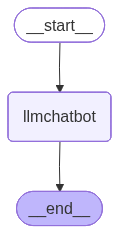

In [10]:
#visualize the graph
from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    pass


In [11]:
response=graph.invoke({"messages":"Hi"})
response

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='225645ce-fc64-438c-b574-52944b824f66'),
  AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.041640949, 'completion_tokens_details': None, 'prompt_time': 0.003439515, 'prompt_tokens_details': None, 'queue_time': 0.048474015, 'total_time': 0.045080464}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_68f543a7cc', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c960f-d24f-7461-9a24-cba3bda79780-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59})]}

In [12]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [13]:
for event in graph.stream({'messages':"Hi"}):
    for value in event.values():
        print(value["messages"][-1].content)
    


It's nice to meet you. Is there something I can help you with or would you like to chat?


### Chatbot with Tool

In [14]:
from langchain_tavily import TavilySearch

tool= TavilySearch(max_results=2)
tool.invoke("what is langgraph")

{'query': 'what is langgraph',
 'response_time': 0.99,
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://huggingface.co/learn/agents-course/en/unit2/langgraph/when_to_use_langgraph',
   'title': 'What is LangGraph ? - Hugging Face Agents Course',
   'content': '# What is LangGraph ? `LangGraph` is a framework developed by LangChain **to manage the control flow of applications that integrate an LLM**. ## When should I use LangGraph ? `LangGraph` is on the other end of the spectrum, it shines when you need **“Control”** on the execution of your agent. LangGraph is particularly valuable when you need **Control over your applications**. It gives you the tools to build an application that follows a predictable process while still leveraging the power of LLMs. Put simply, if your application involves a series of steps that need to be orchestrated in a specific way, with decisions being made at each junction point, **LangGraph provides the structure y

In [15]:
# custom tool
def multiply(a:int, b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b
    
    

In [16]:
tools= [tool, multiply]
llm_with_tools= llm.bind_tools(tools)
llm_with_tools

RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x105d04590>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x105d052b0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a s

In [17]:
## StateGraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


# Node definition
def tool_calling_llm(state:State):
    return { "messages" : [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

#adding edges
builder.add_edge(START, "tool_calling_llm")

builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)

builder.add_edge("tools", END)

graph = builder.compile()


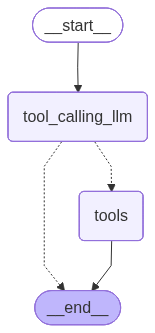

In [18]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
tavily_response = graph.invoke({"messages":"What is the latest AI News"})

In [20]:
for m in tavily_response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the latest AI News
================================== Ai Message ==================================
Tool Calls:
  tavily_search (0x1h60yh0)
 Call ID: 0x1h60yh0
  Args:
    query: latest AI news
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.forbes.com/sites/viviantoh/2026/02/24/china-startups-is-driving-the-future-of-global-robotaxi-deployment/", "title": "China AI Companies Drive The Future Of Global Robotaxi Deployment - Forbes", "score": 0.7676898, "published_date": "Wed, 25 Feb 2026 04:14:28 GMT", "content": "WeRide\n\nThe Prompt: Get the week’s biggest AI news on the buzziest companies and boldest breakthroughs, in your inbox.\n\nEmail Address \n\n Sign Up \n

In [21]:
multiply_response = graph.invoke({'messages':'5+2'})
for m in multiply_response["messages"]:
    m.pretty_print()

================================ Human Message =================================

5+2
================================== Ai Message ==================================
Tool Calls:
  multiply (39s3kfar3)
 Call ID: 39s3kfar3
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


### attaching React Agent Architecture

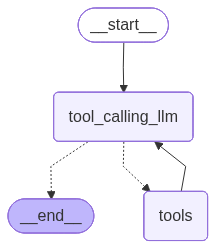

In [22]:
## StateGraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


# Node definition
def tool_calling_llm(state:State):
    return { "messages" : [llm_with_tools.invoke(state["messages"])]}

react_builder = StateGraph(State)
react_builder.add_node("tool_calling_llm", tool_calling_llm)
react_builder.add_node("tools", ToolNode(tools))

#adding edges
react_builder.add_edge(START, "tool_calling_llm")

react_builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)

react_builder.add_edge("tools", "tool_calling_llm")

react_graph = react_builder.compile()

display(Image(react_graph.get_graph().draw_mermaid_png()))

In [25]:
react_agent_response = react_graph.invoke({'messages':'Give me the latest AI news and then add 5 + 2 and then search on wilipedia what is a Blue berry'})
for m in react_agent_response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Give me the latest AI news and then add 5 + 2 and then search on wilipedia what is a Blue berry
================================== Ai Message ==================================
Tool Calls:
  tavily_search (swd40b5a0)
 Call ID: swd40b5a0
  Args:
    query: latest AI news
    topic: news
  multiply (vze2gb9h2)
 Call ID: vze2gb9h2
  Args:
    a: 5
    b: 2
  tavily_search (gn51rcq64)
 Call ID: gn51rcq64
  Args:
    query: what is a blueberry
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.theregister.com/2026/02/19/google_germinates_gemini_31_pro/", "title": "Google germinates Gemini 3.1 Pro in ongoing AI model race - theregister.com", "score": 0.94815457, "published_date": "Thu, 19 Feb 2026 19:57:00 GMT", "content": "

### Adding memory to the Agentic Graph

In [27]:
react_agent_response = react_graph.invoke({'messages':'My name is Satyam'})
for m in react_agent_response["messages"]:
    m.pretty_print()
    
    
react_agent_response = react_graph.invoke({'messages':'what is my name'})
for m in react_agent_response["messages"]:
    m.pretty_print()

================================ Human Message =================================

My name is Satyam
================================== Ai Message ==================================

Hello Satyam! It's nice to meet you. Is there something I can help you with or would you like to chat?
================================ Human Message =================================

what is my name
================================== Ai Message ==================================

I don't have any information about your name. If you'd like to share it, I'd be happy to chat with you.


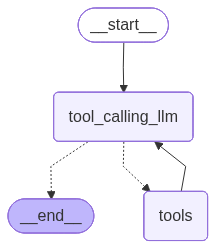

In [28]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

memory = MemorySaver()
# Node definition
def tool_calling_llm(state:State):
    return { "messages" : [llm_with_tools.invoke(state["messages"])]}

memory_builder = StateGraph(State)
memory_builder.add_node("tool_calling_llm", tool_calling_llm)
memory_builder.add_node("tools", ToolNode(tools))

#adding edges
memory_builder.add_edge(START, "tool_calling_llm")

memory_builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)

memory_builder.add_edge("tools", "tool_calling_llm")

memory_graph = memory_builder.compile(checkpointer=memory)

display(Image(memory_graph.get_graph().draw_mermaid_png()))

In [31]:
config={
    "configurable":{
        "thread_id":"1"
    }
}

memory_response = memory_graph.invoke({'messages':'My name is Satyam'},config=config)
for m in memory_response["messages"]:
    m.pretty_print()
    
    
memory_response = memory_graph.invoke({'messages':'what is my name'},config=config)
for m in memory_response["messages"]:
    m.pretty_print()

================================ Human Message =================================

My name is Satyam
================================== Ai Message ==================================

Hello Satyam, it's nice to meet you. Is there something I can help you with or would you like to chat?
================================ Human Message =================================

My name is Satyam
================================== Ai Message ==================================

Hello Satyam, it's nice to meet you. Is there something I can help you with or would you like to chat?
================================ Human Message =================================

what is my name
================================== Ai Message ==================================

Your name is Satyam.


In [32]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

def SuperBot(state: State):
    return { "messages": [llm.invoke(state["messages"])] }



In [ ]:
# class State(TypedDict):
#     messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)

graph_builder.add_node("SuperBot", SuperBot)

graph_builder.add_edge(START, "SuperBot")

graph_builder.add_edge("SuperBot", END)

graph = graph_builder.compile(checkpointer=memory)


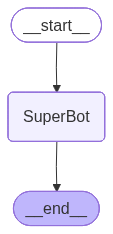

In [37]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [39]:
response = graph.invoke({"messages": "Hi, My name is Satyam and I love playing cricket"}, config=config)
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hi, My name is Satyam and I love playing cricket
================================== Ai Message ==================================

Nice to meet you, Satyam! Cricket is an amazing sport, and it's great to hear that you're passionate about it. Are you a fan of a particular team or player? Do you have a favorite format of the game, like Test cricket, ODIs, or T20s? Or do you enjoy playing the game yourself, perhaps in local tournaments or with friends?


### Streaming

Methods:
    stream()
    astream() -> asy

Additional Parameters:

    mode = updates 
            -> This streams updates to the the state graph after each node is called.

    mode= value -> 
            This streams the full state of the graph after each node is getting called

In [46]:
config ={"configurable":{"thread_id":"3"}}
response = graph.stream({"messages": "Hi, My name is Satyam and I love playing cricket"}, config, stream_mode="updates")
for m in response:
    print(m)

{'SuperBot': {'messages': [AIMessage(content="Hi Satyam, I think we've had a great start to our conversation about cricket. Since you love playing cricket, I'd like to ask: What's your favorite format of the game? Do you enjoy the fast-paced action of T20, the strategy of One-Day Internationals, or the traditional test matches?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 67, 'prompt_tokens': 467, 'total_tokens': 534, 'completion_time': 0.220037052, 'completion_tokens_details': None, 'prompt_time': 0.034313016, 'prompt_tokens_details': None, 'queue_time': 0.049059074, 'total_time': 0.254350068}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c99d1-5458-7691-977e-79db8cb2070f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 467, 'output_tokens': 67, 'total_tokens': 534})]}}


In [47]:
config ={"configurable":{"thread_id":"3"}}
response = graph.stream({"messages": "Hi, My name is Satyam and I love playing cricket"}, config, stream_mode="values")
for m in response:
    print(m)

{'messages': [HumanMessage(content='Hi, My name is Satyam and I love playing cricket', additional_kwargs={}, response_metadata={}, id='5efa22f7-33ed-4896-b8b9-921172c467e1'), AIMessage(content="Nice to meet you, Satyam! Cricket is an amazing sport, and it's great that you're passionate about it. Are you a fan of a particular team or player? Do you play cricket yourself, or do you enjoy watching matches?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 48, 'total_tokens': 99, 'completion_time': 0.182457475, 'completion_tokens_details': None, 'prompt_time': 0.00467962, 'prompt_tokens_details': None, 'queue_time': 0.04904427, 'total_time': 0.187137095}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_68f543a7cc', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c99d0-0b71-7873-9c57-639d237c9bcb-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'in

In [48]:
response = graph.stream({"messages": "I also like football"}, config, stream_mode="values")
for m in response:
    print(m)

{'messages': [HumanMessage(content='Hi, My name is Satyam and I love playing cricket', additional_kwargs={}, response_metadata={}, id='5efa22f7-33ed-4896-b8b9-921172c467e1'), AIMessage(content="Nice to meet you, Satyam! Cricket is an amazing sport, and it's great that you're passionate about it. Are you a fan of a particular team or player? Do you play cricket yourself, or do you enjoy watching matches?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 48, 'total_tokens': 99, 'completion_time': 0.182457475, 'completion_tokens_details': None, 'prompt_time': 0.00467962, 'prompt_tokens_details': None, 'queue_time': 0.04904427, 'total_time': 0.187137095}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_68f543a7cc', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c99d0-0b71-7873-9c57-639d237c9bcb-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'in

In [49]:
response = graph.stream({"messages": "I also like playing games"}, config, stream_mode="updates")
for m in response:
    print(m)

{'SuperBot': {'messages': [AIMessage(content="That's great, Satyam! It sounds like you're a multifaceted person with interests in sports and gaming. What kind of games do you enjoy playing? Are you into console games like PlayStation or Xbox, or do you prefer playing on your PC or mobile device? Are you a fan of popular games like Fortnite, Minecraft, or FIFA, or do you have a soft spot for cricket or football video games?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 86, 'prompt_tokens': 746, 'total_tokens': 832, 'completion_time': 0.286037583, 'completion_tokens_details': None, 'prompt_time': 0.091092684, 'prompt_tokens_details': None, 'queue_time': 0.049329776, 'total_time': 0.377130267}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c99d3-5820-7100-af77-75b0ce5feb02-0', tool_calls=[], invalid_tool_calls

astream()

In [54]:
config ={"configurable":{"thread_id":"5"}}
async for event in graph.astream_events({"messages": "Hi, My name is Satyam and I love playing cricket"}, config, version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi, My name is Satyam and I love playing cricket'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019c99d5-98c2-7e03-a91c-97736d6d5937', 'metadata': {'thread_id': '5'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi, My name is Satyam and I love playing cricket', additional_kwargs={}, response_metadata={}, id='a3f834ab-4026-4327-8535-9de26441e65b'), AIMessage(content="Nice to meet you, Satyam! Cricket is an exciting sport, and it's great that you're passionate about it. Are you a fan of a particular team or player? Do you play cricket yourself, or do you enjoy watching matches?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 48, 'total_tokens': 99, 'completion_time': 0.201581906, 'completion_tokens_details': None, 'prompt_time': 0.002442029, 'prompt_tokens_details': None, 'queue_time': 0.055812261, 'total_time': 0.204023